# ANN pipeline:

1. Loads a CSV

2. Splits into train & test

3. Applies StandardScaler and saves the scaler

4. Builds, trains, evaluates an ANN model, and saves it

5. Takes an image input from the user, preprocesses it, and outputs prediction + probability + actual class name

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [2]:
# =======================
# 1. LOAD CSV
# =======================
train_path = "GAN_based_train_features_data_with_actual_label.csv"
test_path = "GAN_based_test_features_data_with_actual_label.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

display(train_df.head())

display(test_df.head())

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,actual_label
0,3.301308,0.000000,9.975002,0.019766,3.717488,0.255586,0.000000,11.859056,1.169669,0.912872,...,0.000000,5.293978,2.234601,0.592527,0.000000,0.000000,0.000000,0.623889,0.000000,7
1,0.000000,0.071855,0.000000,0.430537,1.641706,0.393178,0.871468,0.000000,0.164860,0.000000,...,0.015511,2.987143,4.407417,0.250392,0.398444,0.000000,0.065622,0.253377,0.000000,1
2,0.284118,0.000000,2.040479,0.032298,2.006461,0.421232,0.000000,13.170566,0.616349,2.606158,...,0.734768,0.756418,0.000000,5.090756,0.000000,2.960966,1.413547,2.158964,0.378692,13
3,3.327098,1.914030,0.913072,0.000000,18.186752,7.293949,3.674279,1.130466,7.473991,0.000000,...,0.983407,1.191619,11.486649,0.373138,0.005826,0.442352,7.642914,3.619562,3.577333,10
4,5.382783,3.409659,17.433770,0.396771,5.820237,0.000000,2.089081,7.037065,4.133208,0.740246,...,1.710192,0.667342,9.979090,0.789752,0.853683,2.653501,1.423639,1.592949,1.331623,7


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,actual_label
0,0.005013,0.487069,0.077972,1.456042,0.184264,1.819208,0.000000,0.000000,4.262309,2.324724,...,3.440139,0.520727,0.234967,2.369392,0.699561,7.080271,2.120606,0.447268,2.158136,6
1,1.408318,0.000000,4.400403,0.005092,2.747638,3.175923,0.000000,0.154343,0.000000,0.245769,...,0.126170,8.473223,0.084553,4.950424,0.099895,0.000000,0.000000,0.620197,0.000000,9
2,3.120856,0.000000,5.985402,1.147433,2.117604,0.000000,0.000000,0.089881,0.000000,7.759985,...,0.101556,1.079278,1.935814,0.495570,1.061596,0.000000,0.000000,3.429099,0.498064,12
3,1.702185,3.605569,0.027688,6.391105,1.944592,0.000000,0.135604,1.463124,0.091565,1.588057,...,0.000000,1.040627,4.240038,0.042447,0.000000,0.501174,12.590919,2.372110,0.000000,17
4,9.266862,0.507491,13.136552,0.174197,2.667798,11.523331,0.000000,2.417068,0.000000,8.511418,...,0.745214,4.066996,26.006353,17.196577,0.168782,0.000000,0.742808,1.286201,3.700851,17


In [3]:
# Train-test split
target_column = 'actual_label'
X_train, y_train = train_df.drop(columns=target_column), train_df[target_column]
X_test, y_test = test_df.drop(columns=target_column), test_df[target_column]


In [4]:
# =======================
# 3. STANDARD SCALER & SAVE
# =======================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "GAN_ANN_scaler.pkl")


['GAN_ANN_scaler.pkl']

In [12]:
# =======================
# 4. BUILD ANN MODEL
# =======================
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(y_train.nunique(), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)  

Epoch 1/10

246/246 [==============================] - 107s 35ms/step - loss: 0.2864 - accuracy: 0.9234 - val_loss: 0.0143 - val_accuracy: 0.9954
Epoch 2/10
246/246 [==============================] - 2s 9ms/step - loss: 0.0173 - accuracy: 0.9963 - val_loss: 0.0020 - val_accuracy: 0.9990
Epoch 3/10
246/246 [==============================] - 2s 8ms/step - loss: 0.0106 - accuracy: 0.9967 - val_loss: 0.0021 - val_accuracy: 0.9985
Epoch 4/10
246/246 [==============================] - 2s 8ms/step - loss: 0.0074 - accuracy: 0.9981 - val_loss: 0.0020 - val_accuracy: 0.9985
Epoch 5/10
246/246 [==============================] - 2s 9ms/step - loss: 0.0063 - accuracy: 0.9980 - val_loss: 0.0029 - val_accuracy: 0.9990
Epoch 6/10
246/246 [==============================] - 2s 8ms/step - loss: 0.0075 - accuracy: 0.9975 - val_loss: 0.0034 - val_accuracy: 0.9985
Epoch 7/10
246/246 [==============================] - 2s 8ms/step - loss: 0.0042 - accuracy: 0.9987 - val_loss: 0.0018 - val_accuracy: 0.9990
Ep

In [14]:
# Evaluate model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

306/306 [==============================] - 1s 2ms/step - loss: 0.2027 - accuracy: 0.9466
Test Accuracy: 0.9466
Test Loss: 0.2027


In [15]:
# Save model
model.save("gan_ann_model.h5")

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [41]:
import glob

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, cohen_kappa_score, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, cohen_kappa_score, log_loss

In [36]:
def evaluate_model(test_labels, pred_labels):
    '''
    This function is use to model evaluation.
    
    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.
    
    Output: None
    
    '''
    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    

307/307 [==============================] - 1s 3ms/step
Accuracy: 98.63 %
Log Loss: 1.37 %
Cohen's Kappa Score: 98.55 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       546
           1       1.00      0.98      0.99       540
           2       1.00      1.00      1.00       546
           3       1.00      0.97      0.99       547
           4       1.00      1.00      1.00       542
           5       1.00      1.00      1.00       544
           6       0.95      1.00      0.98       545
           7       1.00      1.00      1.00       546
           8       1.00      1.00      1.00       543
           9       1.00      0.85      0.92       553
          10       0.97      1.00      0.99       543
          11       0.91      1.00      0.95       549
          12       1.00      1.00      1.00       540
          13       1.00      1.00      1.00       541
          14       1.00      1.00      1.00   

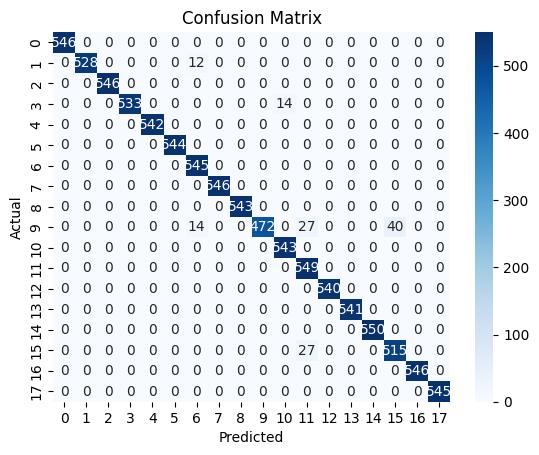

,0,1,2,3,4,5,6,7,8,9,...,504,505,506,507,508,509,510,511,actual_label,pred_label
0,3.301308,0.000000,9.975002,0.019766,3.717488,0.255586,0.000000,11.859056,1.169669,0.912872,...,5.293978,2.234601,0.592527,0.000000,0.000000,0.000000,0.623889,0.000000,7,7
1,0.000000,0.071855,0.000000,0.430537,1.641706,0.393178,0.871468,0.000000,0.164860,0.000000,...,2.987143,4.407417,0.250392,0.398444,0.000000,0.065622,0.253377,0.000000,1,1
2,0.284118,0.000000,2.040479,0.032298,2.006461,0.421232,0.000000,13.170566,0.616349,2.606158,...,0.756418,0.000000,5.090756,0.000000,2.960966,1.413547,2.158964,0.378692,13,13
3,3.327098,1.914030,0.913072,0.000000,18.186752,7.293949,3.674279,1.130466,7.473991,0.000000,...,1.191619,11.486649,0.373138,0.005826,0.442352,7.642914,3.619562,3.577333,10,10
4,5.382783,3.409659,17.433770,0.396771,5.820237,0.000000,2.089081,7.037065,4.133208,0.740246,...,0.667342,9.979090,0.789752,0.853683,2.653501,1.423639,1.592949,1.331623,7,7


In [37]:
# Prediction
preds = model.predict(X_train_scaled)
y_pred = np.argmax(preds, axis=1)

evaluate_model(y_train, y_pred)

train_df['pred_label'] = y_pred
train_df.head()

306/306 [==============================] - 1s 2ms/step
Accuracy: 94.66 %
Log Loss: 5.34 %
Cohen's Kappa Score: 94.35 %

classification_report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       542
           1       1.00      0.96      0.98       546
           2       1.00      1.00      1.00       542
           3       1.00      0.92      0.96       542
           4       0.96      0.88      0.92       542
           5       1.00      1.00      1.00       544
           6       0.83      0.96      0.89       544
           7       1.00      1.00      1.00       541
           8       0.96      0.92      0.94       546
           9       0.90      0.73      0.81       542
          10       0.96      1.00      0.98       540
          11       0.87      1.00      0.93       544
          12       1.00      0.92      0.96       543
          13       1.00      0.85      0.92       542
          14       1.00      0.96      0.98   

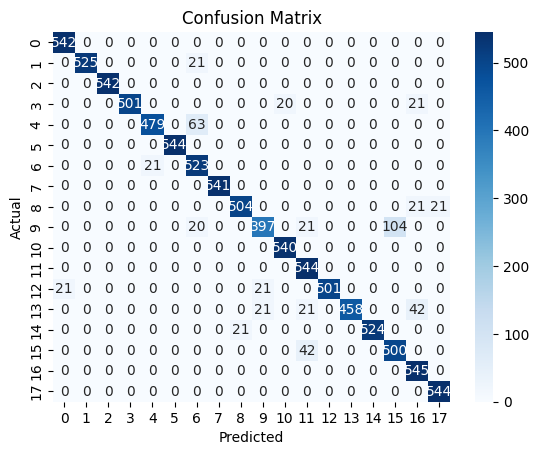

,0,1,2,3,4,5,6,7,8,9,...,504,505,506,507,508,509,510,511,actual_label,pred_label
0,0.005013,0.487069,0.077972,1.456042,0.184264,1.819208,0.000000,0.000000,4.262309,2.324724,...,0.520727,0.234967,2.369392,0.699561,7.080271,2.120606,0.447268,2.158136,6,6
1,1.408318,0.000000,4.400403,0.005092,2.747638,3.175923,0.000000,0.154343,0.000000,0.245769,...,8.473223,0.084553,4.950424,0.099895,0.000000,0.000000,0.620197,0.000000,9,9
2,3.120856,0.000000,5.985402,1.147433,2.117604,0.000000,0.000000,0.089881,0.000000,7.759985,...,1.079278,1.935814,0.495570,1.061596,0.000000,0.000000,3.429099,0.498064,12,12
3,1.702185,3.605569,0.027688,6.391105,1.944592,0.000000,0.135604,1.463124,0.091565,1.588057,...,1.040627,4.240038,0.042447,0.000000,0.501174,12.590919,2.372110,0.000000,17,17
4,9.266862,0.507491,13.136552,0.174197,2.667798,11.523331,0.000000,2.417068,0.000000,8.511418,...,4.066996,26.006353,17.196577,0.168782,0.000000,0.742808,1.286201,3.700851,17,17


In [39]:
# Prediction
preds = model.predict(X_test_scaled)
y_pred = np.argmax(preds, axis=1)

evaluate_model(y_test, y_pred)

test_df['pred_label'] = y_pred
test_df.head()

In [44]:
img_dir = os.path.join('..', 'Dataset', 'artefact2', 'train', '*') 
image_class = sorted([path.split('\\')[-1] for path in glob.glob(img_dir)])
idx_to_class = {k: v for k, v in enumerate(image_class)}
# print(idx_to_class)

In [45]:
train_df['actual_class'] = train_df['actual_label'].apply(lambda x: idx_to_class[x])
train_df['pred_class'] = train_df['pred_label'].apply(lambda x: idx_to_class[x])
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,506,507,508,509,510,511,actual_label,pred_label,actual_class,pred_class
0,3.301308,0.000000,9.975002,0.019766,3.717488,0.255586,0.000000,11.859056,1.169669,0.912872,...,0.592527,0.000000,0.000000,0.000000,0.623889,0.000000,7,7,lion,lion
1,0.000000,0.071855,0.000000,0.430537,1.641706,0.393178,0.871468,0.000000,0.164860,0.000000,...,0.250392,0.398444,0.000000,0.065622,0.253377,0.000000,1,1,blue_whale,blue_whale
2,0.284118,0.000000,2.040479,0.032298,2.006461,0.421232,0.000000,13.170566,0.616349,2.606158,...,5.090756,0.000000,2.960966,1.413547,2.158964,0.378692,13,13,siamese_cat,siamese_cat
3,3.327098,1.914030,0.913072,0.000000,18.186752,7.293949,3.674279,1.130466,7.473991,0.000000,...,0.373138,0.005826,0.442352,7.642914,3.619562,3.577333,10,10,ox,ox
4,5.382783,3.409659,17.433770,0.396771,5.820237,0.000000,2.089081,7.037065,4.133208,0.740246,...,0.789752,0.853683,2.653501,1.423639,1.592949,1.331623,7,7,lion,lion


In [46]:
test_df['actual_class'] = test_df['actual_label'].apply(lambda x: idx_to_class[x])
test_df['pred_class'] = test_df['pred_label'].apply(lambda x: idx_to_class[x])
test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,506,507,508,509,510,511,actual_label,pred_label,actual_class,pred_class
0,0.005013,0.487069,0.077972,1.456042,0.184264,1.819208,0.000000,0.000000,4.262309,2.324724,...,2.369392,0.699561,7.080271,2.120606,0.447268,2.158136,6,6,killer_whale,killer_whale
1,1.408318,0.000000,4.400403,0.005092,2.747638,3.175923,0.000000,0.154343,0.000000,0.245769,...,4.950424,0.099895,0.000000,0.000000,0.620197,0.000000,9,9,mouse,mouse
2,3.120856,0.000000,5.985402,1.147433,2.117604,0.000000,0.000000,0.089881,0.000000,7.759985,...,0.495570,1.061596,0.000000,0.000000,3.429099,0.498064,12,12,rhinoceros,rhinoceros
3,1.702185,3.605569,0.027688,6.391105,1.944592,0.000000,0.135604,1.463124,0.091565,1.588057,...,0.042447,0.000000,0.501174,12.590919,2.372110,0.000000,17,17,walrus,walrus
4,9.266862,0.507491,13.136552,0.174197,2.667798,11.523331,0.000000,2.417068,0.000000,8.511418,...,17.196577,0.168782,0.000000,0.742808,1.286201,3.700851,17,17,walrus,walrus


## Working with Unseen Dataset

In [72]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

from PIL import Image
import csv

from sentence_transformers import SentenceTransformer, util
import torch

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [69]:
# Build a DCGAN
# Generator (Feature Generator)
def build_generator(noise_dim, output_dim):
    input_noise = Input(shape=(noise_dim,))
    x = Dense(128, activation='relu')(input_noise)
    x = Dense(output_dim, activation='linear')(x)  # match feature vector size
    model = Model(input_noise, x)
    return model

# Discriminator
def build_discriminator(input_dim):
    input_feat = Input(shape=(input_dim,))
    x = Dense(128)(input_feat)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(input_feat, x)
    return model

def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# Create the feature extractor
feature_extractor = build_feature_extractor()

# Feature Extractor 
img_dir = os.path.join('..', 'Dataset', 'artefact2', 'unseen', '*', '*') # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)

for img_path in image_paths:
    act_class = img_path.split('\\')[-2]
#     print(act_class)
    
    # Preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Extract features & predict
    features = feature_extractor.predict(img_array, verbose=0)
    features = scaler.transform(features)
    preds = model.predict(features)
    confidence = np.max(preds)
    y_pred = np.argmax(preds, axis=1)[0]
    class_name = idx_to_class[y_pred]
    
    # Write header once
    csv_file_path = 'Unseen_MLmodels\\GAN_ANN_prediction_results_generator_unseen.csv'
    if not os.path.exists(csv_file_path):
        with open(csv_file_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

    # Log to CSV
    with open(csv_file_path, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([img_path, act_class, y_pred, class_name, f"{confidence:.4f}"])
    

1/1 [==============================] - 0s 21ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 21ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 21ms/step


...

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 25ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 27ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [75]:
SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2')

img_dir = os.path.join('..', 'Dataset', 'artefact2', 'unseen', '*') # '../Dataset/artefact2/test/*'
image_class = sorted([path.split('\\')[-1] for path in glob.glob(img_dir)])
idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}

words = list(idx_to_unseen_class.values()) 
embeddings = SentenceTransformer_model.encode(words, convert_to_tensor=True)

unseen_csv_file_path = 'Unseen_MLmodels\\GAN_ANN_prediction_results_generator_unseen.csv'
df = pd.read_csv(unseen_csv_file_path)
# display(df.head())
    
similar_wds = []

for _, row in df.iterrows():
#     print(row[-2])
    # Find top n similar 
    query = SentenceTransformer_model.encode(row[-2], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
#         print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx]) 
        cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
#     break
    similar_wds.append((wds, cos_scores))

df['similar_wds'] = similar_wds
display(df.head())

df.to_csv(unseen_csv_file_path, index=False)
print('-'*50, ' END ', '-'*50, '\n')



,Image Path,Actual Class,Predicted Class,Class Name,Probability,similar_wds
0,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,1.0000,"([chimpanzee, rat, leopard, raccoon, giant_pan..."
1,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.9999,"([chimpanzee, hippopotamus, raccoon, humpback_..."
2,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.6937,"([chimpanzee, rat, leopard, raccoon, giant_pan..."
3,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.9865,"([chimpanzee, rat, leopard, raccoon, giant_pan..."
4,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.9922,"([chimpanzee, rat, leopard, raccoon, giant_pan..."


--------------------------------------------------  END  -------------------------------------------------- 



Accuracy: 58.00 %
Log Loss: 42.00 %
Cohen's Kappa Score: 53.33 %

classification_report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.33      1.00      0.50        10
           4       0.77      1.00      0.87        10
           5       1.00      0.20      0.33        10
           6       1.00      0.70      0.82        10
           7       0.75      0.90      0.82        10
           8       0.42      1.00      0.59        10
           9       1.00      0.20      0.33        10

    accuracy                           0.58       100
   macro avg       0.61      0.58      0.51       100
weighted avg       0.61      0.58      0.51       100



C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

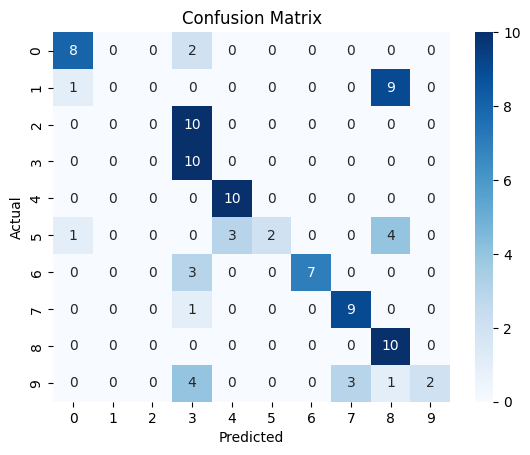

--------------------------------------------------  END  -------------------------------------------------- 



In [78]:
df = pd.read_csv(unseen_csv_file_path)
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():    
    ActualClass = row[1]
    SimilarWords = eval(row[-1])[0]

    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
#     display(df.head())

test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
evaluate_model(test_labels, pred_labels)

df.to_csv(unseen_csv_file_path, index=False)
print('-'*50, ' END ', '-'*50, '\n')